<a href="https://colab.research.google.com/github/mishrasatyam9720-debug/house-price-prediction/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
from xgboost import XGBRegressor
import sklearn.datasets

In [2]:
house_price_prediction = sklearn.datasets.fetch_california_housing()

In [3]:
print ( house_price_prediction)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [4]:
df = pd.DataFrame(house_price_prediction.data , columns = house_price_prediction.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
df["price"] = house_price_prediction.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
correlation = df.corr()

<Axes: >

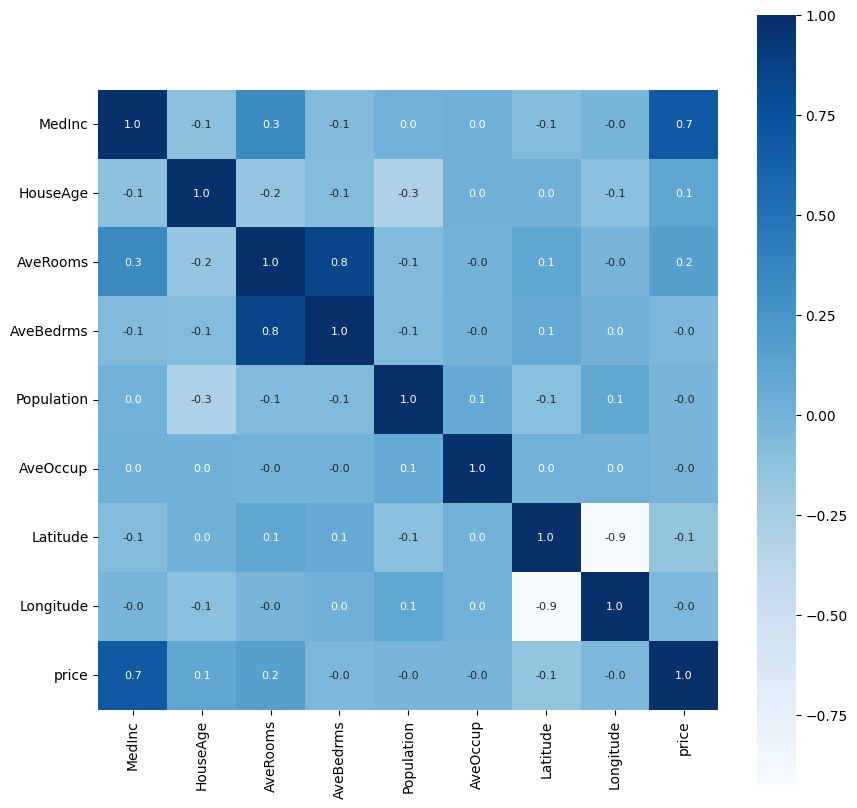

In [10]:
plt.figure(figsize=(10,10))

sns.heatmap(
    correlation,
    cbar=True,
    square=True,
    fmt='.1f',
    annot=True,
    annot_kws={'size':8},
    cmap='Blues'
)

In [11]:
x = df.drop("price", axis=1)
y = df["price"]

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)


--- Training and Evaluating: XGBoost ---
R squared error (Training) : 0.947186443380359
Mean Absolute Error (Training) : 0.18885009247854148
R squared error (Test) : 0.8370813165448978
Mean Absolute Error (Test) : 0.3079223702763229


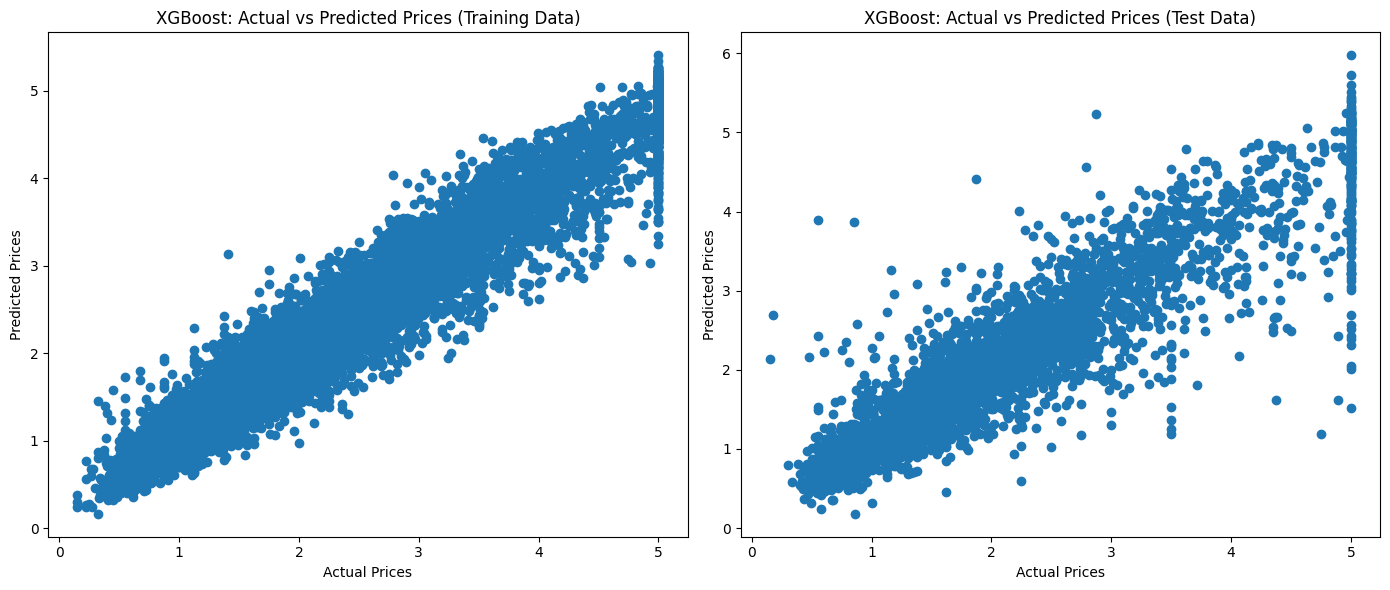


--- Training and Evaluating: RandomForest ---
R squared error (Training) : 0.9737499757303769
Mean Absolute Error (Training) : 0.12089157579941899
R squared error (Test) : 0.8080057727696555
Mean Absolute Error (Test) : 0.33051492269864363


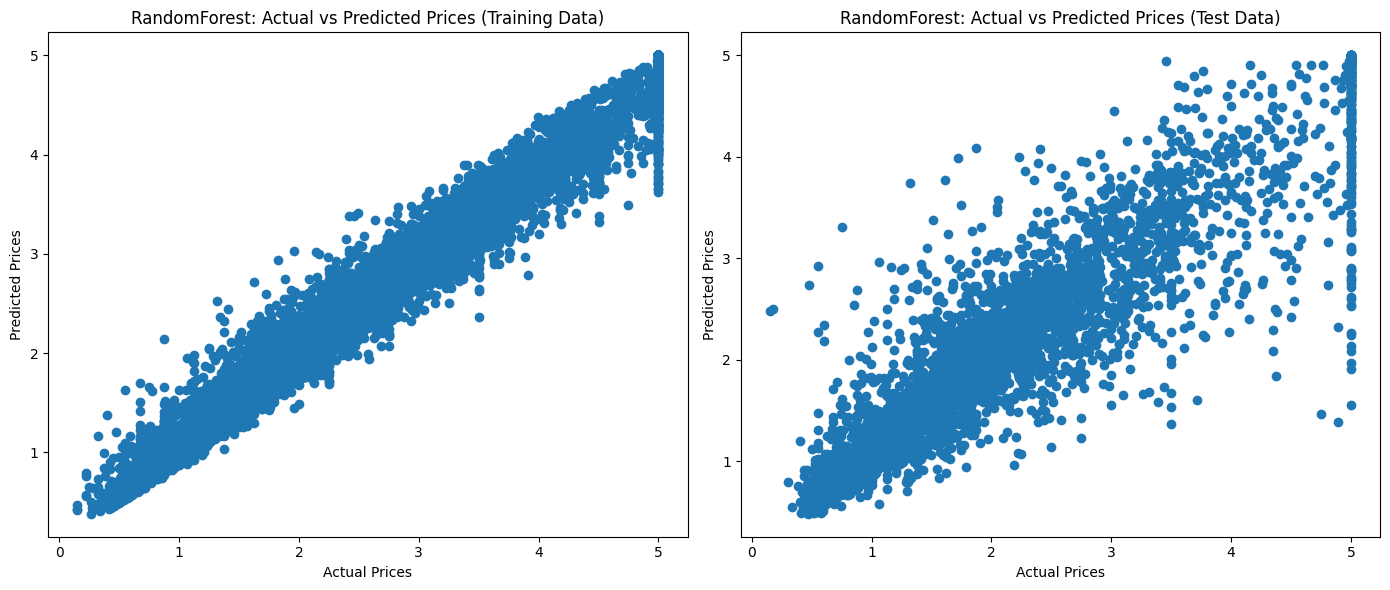

In [23]:
from sklearn.ensemble import RandomForestRegressor

models = {"XGBoost": XGBRegressor(), "RandomForest": RandomForestRegressor()}


model = None

for name, current_model in models.items():
  print(f"\n--- Training and Evaluating: {name} ---")
  current_model.fit(x_train, y_train)

  training_data_prediction = current_model.predict(x_train)

  score_1 = metrics.r2_score(y_train, training_data_prediction)
  score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)

  print(f"R squared error (Training) : {score_1}")
  print(f"Mean Absolute Error (Training) : {score_2}")

  test_data_prediction = current_model.predict(x_test)

  score_3 = metrics.r2_score(y_test, test_data_prediction)
  score_2_test = metrics.mean_absolute_error(y_test, test_data_prediction)
  print(f"R squared error (Test) : {score_3}")
  print(f"Mean Absolute Error (Test) : {score_2_test}")

  plt.figure(figsize=(14, 6))
  plt.subplot(1, 2, 1)
  plt.scatter(y_train, training_data_prediction)
  plt.xlabel("Actual Prices")
  plt.ylabel("Predicted Prices")
  plt.title(f"{name}: Actual vs Predicted Prices (Training Data)")

  plt.subplot(1, 2, 2)
  plt.scatter(y_test, test_data_prediction)
  plt.xlabel("Actual Prices")
  plt.ylabel("Predicted Prices")
  plt.title(f"{name}: Actual vs Predicted Prices (Test Data)")
  plt.tight_layout()
  plt.show()


  model = current_model



In [24]:
input_data = np.asarray([8.3252, 41.0, 6.984127, 1.023810, 322.0, 2.555556, 37.88, -122.23]).reshape(1, -1)
price_prediction=model.predict(input_data)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [25]:
print(price_prediction)

[4.4077607]
